In [1]:
MODEL_CLS = "vae"
PATH_WORK_DIR = "../.."
PATH_CONFIG_FILE = f"./config/{MODEL_CLS}.yaml"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.chdir(PATH_WORK_DIR)
print(f"DIRECTORY: {os.getcwd()}")

DIRECTORY: c:\Users\jayar\Desktop\바탕 화면\REPO\PROJECT\M1-PJT_ML


In [4]:
import sys
sys.path.append("src")

# Packages

In [5]:
import pandas as pd
from anomaly.stochastic import config, pipeline, trainer, evaluator, utils
import autoencoder

In [ ]:
cfg = config.builder.config_builder(PATH_CONFIG_FILE)

In [7]:
utils.seed.main(cfg.seed)

ALL SEEDS RESET: 42


# Data Preparation

In [8]:
PATH = f"./data/creditcard.csv"
origin = pd.read_csv(PATH)

In [9]:
DROP_COL = ["Time", "Amount"]
df = origin.drop(columns=DROP_COL)

In [10]:
Y_COL = "Class"

kwargs = dict(
    df=df,
    y_col=Y_COL,
    cfg=cfg.pipeline,
)

dataloaders = pipeline.builder.pipeline_builder(**kwargs)

# Modeling

In [11]:
kwargs = dict(
    **cfg.model.params,
)

model = autoencoder.vae.VariationalAutoEncoder(**kwargs)

# Train

In [12]:
kwargs = dict(
    model=model,
    cfg=cfg.trainer,
)

trainer = trainer.builder.trainer_builder(**kwargs)

In [13]:
kwargs = dict(
    trn_loader=dataloaders["trn"],
    val_loader=dataloaders["val"],
)

records = trainer.fit(**kwargs)

VALIDATION
	BEST SCORE: 0.0988
	BEST EPOCH: 37


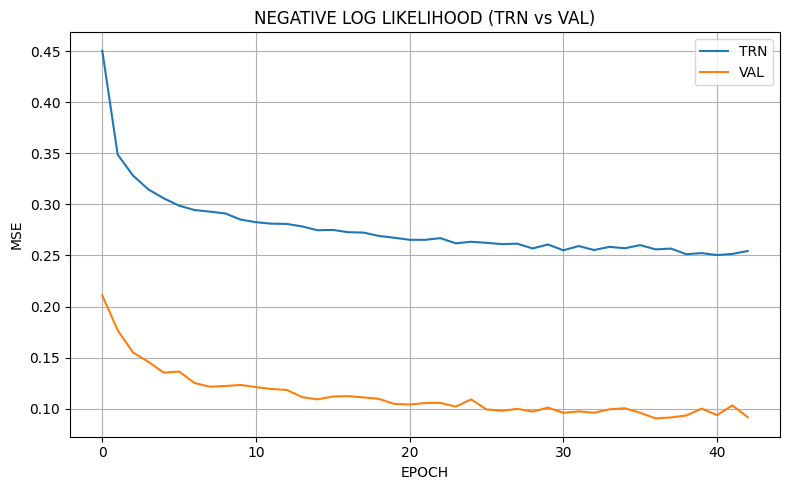

In [14]:
kwargs = dict(
    objs=(records["trn"]["nll"], records["val"]["nll"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="MSE",
    title="NEGATIVE LOG LIKELIHOOD (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

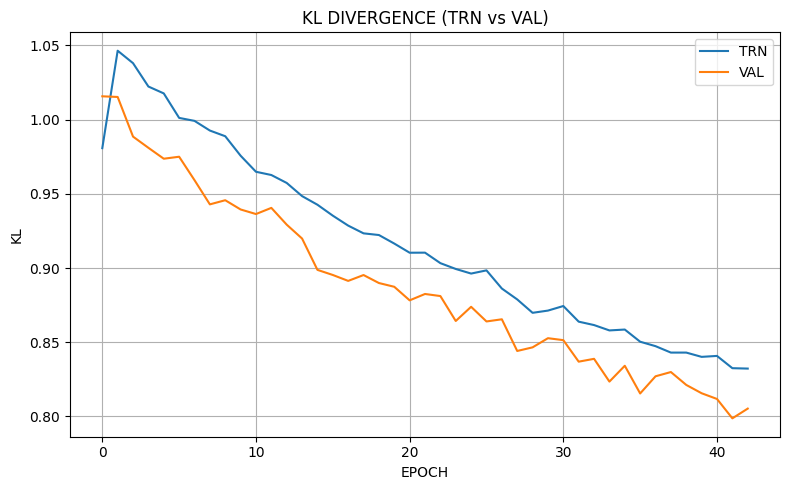

In [15]:
kwargs = dict(
    objs=(records["trn"]["kl"], records["val"]["kl"]),
    labels=("TRN", "VAL"),
    xlabel="EPOCH",
    ylabel="KL",
    title="KL DIVERGENCE (TRN vs VAL)",
    figsize=(8,5),
)

utils.visualizer.main(**kwargs)

# Evaluation

In [16]:
kwargs = dict(
    model=model,
    scores=records["anomaly"],
    cfg=cfg.evaluator,
)

eval = evaluator.builder.evaluator_builder(**kwargs)

In [17]:
result, metrics_sheet = eval(dataloaders["tst"])

TST: 100%|██████████| 8/8 [00:00<00:00, 265.43it/s]


In [18]:
metrics_sheet

,p,threshold,tp,tn,fp,fn,accuracy,precision,recall,f1
0,0.950,0.217720,424,470,22,68,0.908537,0.950673,0.861789,0.904051
1,0.955,0.232100,424,473,19,68,0.911585,0.957111,0.861789,0.906952
2,0.960,0.248775,422,474,18,70,0.910569,0.959091,0.857724,0.905579
3,0.965,0.272388,422,477,15,70,0.913618,0.965675,0.857724,0.908504
4,0.970,0.300961,420,483,9,72,0.917683,0.979021,0.853659,0.912052
5,0.975,0.341409,418,486,6,74,0.918699,0.985849,0.849594,0.912664
6,0.980,0.400108,414,489,3,78,0.917683,0.992806,0.841463,0.910891
7,0.985,0.492560,411,491,1,81,0.916667,0.997573,0.835366,0.909292
8,0.990,0.663653,408,491,1,84,0.913618,0.997555,0.829268,0.905660
9,0.995,1.122185,400,492,0,92,0.906504,1.000000,0.813008,0.896861


# Save

In [ ]:
PATH = f'./result/score/{cfg.model_cls}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
result.to_csv(**kwargs)

In [ ]:
PATH = f'./result/metric/{cfg.model_cls}.csv'

kwargs = dict(
    path_or_buf=PATH,
    index=False,
)
metrics_sheet.to_csv(**kwargs)

In [21]:
PATH = f'./checkpoints/{cfg.model_cls}.pth'

kwargs = dict(
    obj=model,
    path=PATH,
)

utils.checkpointer.save(**kwargs)